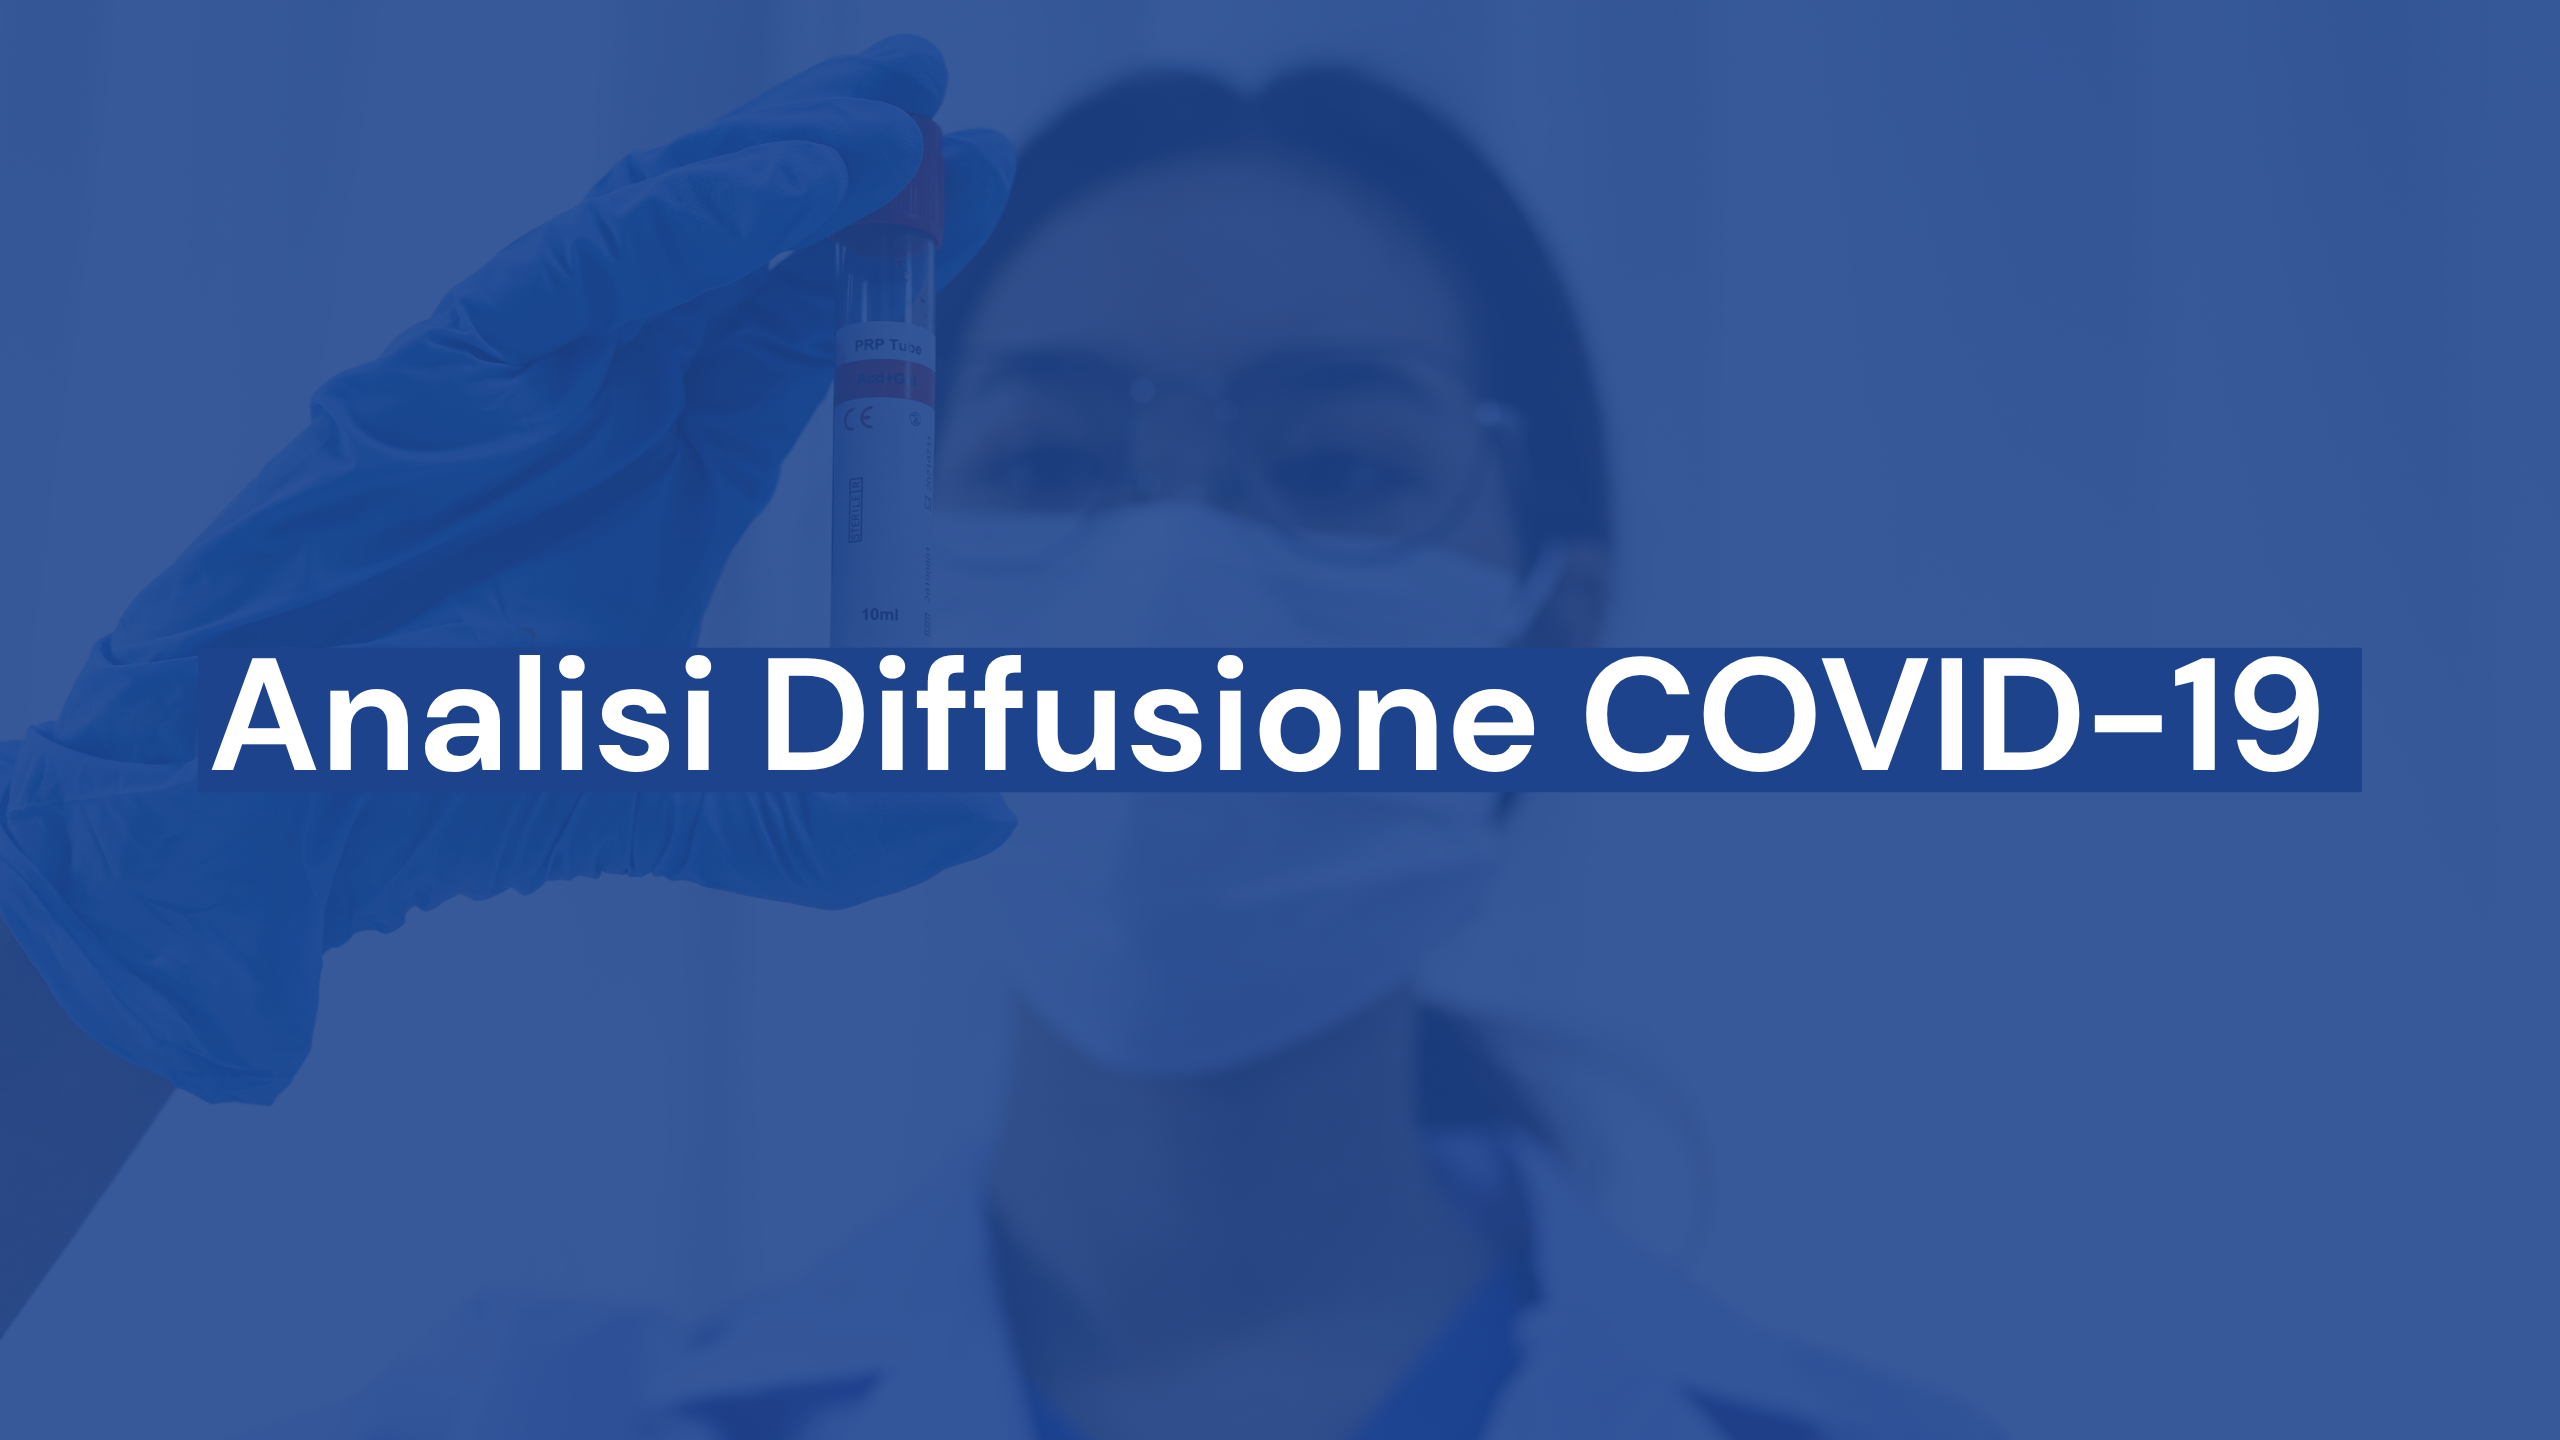

Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv

In [1]:
# Prima di iniziare, importo il dataset tramite la libreria Pandas utilizzando l'URL fornito.
# Verifico poi che il collegamento sia avvenuto correttamente caricando i dati in un DataFrame.

import pandas as pd
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)
df.head(15)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
5,AFG,Asia,Afghanistan,2020-01-10,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
6,AFG,Asia,Afghanistan,2020-01-11,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
7,AFG,Asia,Afghanistan,2020-01-12,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
8,AFG,Asia,Afghanistan,2020-01-13,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
9,AFG,Asia,Afghanistan,2020-01-14,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


# **1. Si richiede di verificare le dimensioni del dataset e i relativi metadati:**

In [ ]:
# Dimensioni del dataframe (righe, colonne)
# Metadati del dataframe

df = pd.read_csv(url)
print("Dimensioni del dataframe (righe, colonne):" , df.shape)
print("Metadati del dataframe: " , df.info())

Dimensioni del dataframe (righe, colonne): (429435, 67)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smo

**Osservazioni sui metadati:**

**Formato dei dati:** La colonna date è classificata come object (testo); sarà quindi necessaria una conversione in formato data per l'analisi temporale.

**Struttura geografica:** La differenza tra i record di location e continent indica che il dataset include sia singoli paesi che aggregati regionali. È fondamentale filtrare i dati per evitare duplicati nel calcolo dei totali per area geografica.

# **2. Si chiede di trovare, per ogni continente:**

**A) il numero di casi fin dall'inizio della pandemia**

**B) la percentuale rispetto al totale mondiale del numero di casi**

In [ ]:
#numero di casi fin dall'inizio della pandemia
lista_continenti = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
df_continenti = df[df['location'].isin(lista_continenti)]

casi_per_continente = df_continenti.groupby('location')['total_cases'].max()
print("Numero di casi per continente:")
print(casi_per_continente)

#percentuale rispetto al totale mondiale del numero di casi
casi_mondiali = df[df['location'] == 'World']['total_cases'].max()
percentuale_casi = (casi_per_continente / casi_mondiali) * 100

print("\nPercentuale dei casi rispetto al totale mondiale:")
print(percentuale_casi)



Numero di casi per continente:
location
Africa            13145380.0
Asia             301499099.0
Europe           252916868.0
North America    124492666.0
Oceania           15003352.0
South America     68809418.0
Name: total_cases, dtype: float64

Percentuale dei casi rispetto al totale mondiale:
location
Africa            1.694283
Asia             38.859648
Europe           32.597976
North America    16.045624
Oceania           1.933754
South America     8.868716
Name: total_cases, dtype: float64


**Analisi dei casi per continente:**

Per ottenere i dati richiesti, è stato applicato un filtro sulla colonna location per isolare esclusivamente i territori continentali. Poiché la metrica total_cases è di tipo cumulativo, è stato utilizzato il metodo .max() per identificare il numero totale di casi registrati dall'inizio della pandemia fino all'ultimo aggiornamento disponibile. Il calcolo percentuale permette invece di contestualizzare l'impatto epidemiologico di ogni area rispetto alla situazione globale (rappresentata dal valore 'World').

# **3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:**

**A) l'evoluzione del casi totali dall'inizio alla fine dell'anno**

**B) il numero di nuovi casi rispetto alla data testo in grassetto**

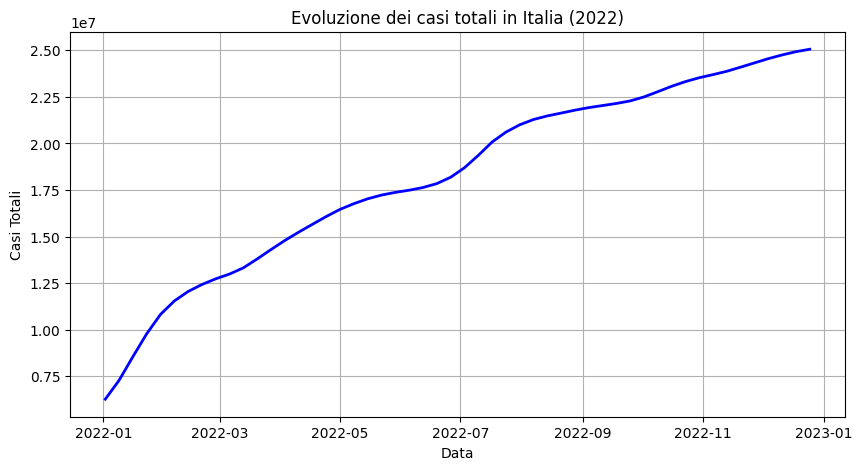

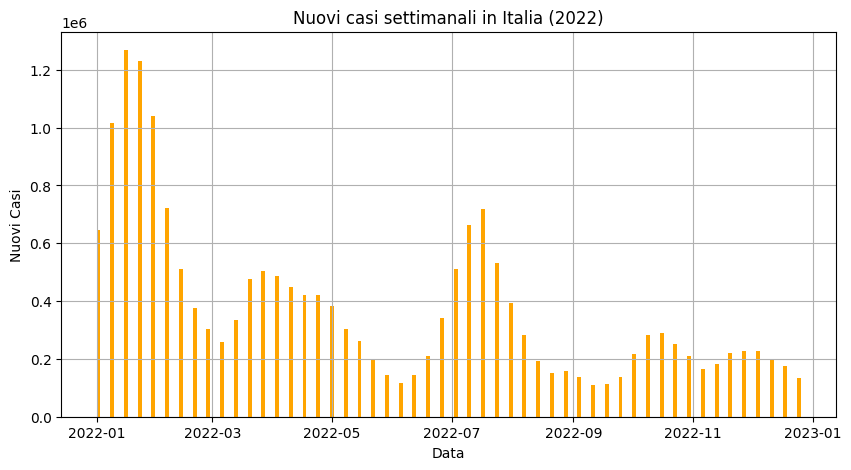

In [ ]:
# Converto la colonna 'date' in formato datetime
df['date'] = pd.to_datetime(df['date'])

# Filtro per l'Italia e per l'anno 2022
italia_2022 = df[(df['location'] == 'Italy') & (df['date'].dt.year == 2022)].copy()

# Rimuovo le righe dove 'new_cases' è nullo o uguale a zero
italia_2022 = italia_2022.dropna(subset=['new_cases'])
italia_2022 = italia_2022[italia_2022['new_cases'] > 0]

# Grafico A: Evoluzione dei casi totali
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(italia_2022['date'], italia_2022['total_cases'], color='blue', linewidth=2)
plt.title('Evoluzione dei casi totali in Italia (2022)')
plt.xlabel('Data')
plt.ylabel('Casi Totali')
plt.grid(True)
plt.show()

# Grafico B: Nuovi casi rispetto alla data
plt.figure(figsize=(10, 5))
plt.bar(italia_2022['date'], italia_2022['new_cases'], color='orange', width=2)
plt.title('Nuovi casi settimanali in Italia (2022)')
plt.xlabel('Data')
plt.ylabel('Nuovi Casi')
plt.grid(True)
plt.show()

**Analisi e Visualizzazione Italia 2022:**

Per questa analisi, i dati sono stati filtrati per isolare l'anno 2022 nel contesto italiano. È stata effettuata una pulizia dei dati rimuovendo i valori nulli e i giorni senza registrazioni per garantire la precisione dei grafici.

**Il Grafico A (linee)** mostra l'andamento cumulativo dei casi, evidenziando la crescita costante del totale nazionale.

**Il Grafico B (barre)** visualizza invece l'incidenza puntuale dei nuovi casi, permettendo di identificare chiaramente i picchi epidemici stagionali verificatisi durante l'anno.

# **4. Riguardo le nazioni di Italia, Germania e Francia:**

**A) mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)**

**B) scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante**

Statistiche descrittive (Maggio 2022 - Aprile 2023):
          count         mean         std    min    25%    50%     75%     max
location                                                                     
France    335.0   998.379104  220.152715  699.0  803.0  972.0  1145.5  1557.0
Germany   365.0  1022.386301  306.113714  512.0  753.0  994.0  1221.0  1842.0
Italy     365.0   231.254795   91.607400   82.0  157.0  227.0   310.0   434.0


/tmp/ipykernel_6987/2802543381.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="location", y="icu_patients", data=confronto_ue, palette="Pastel1")


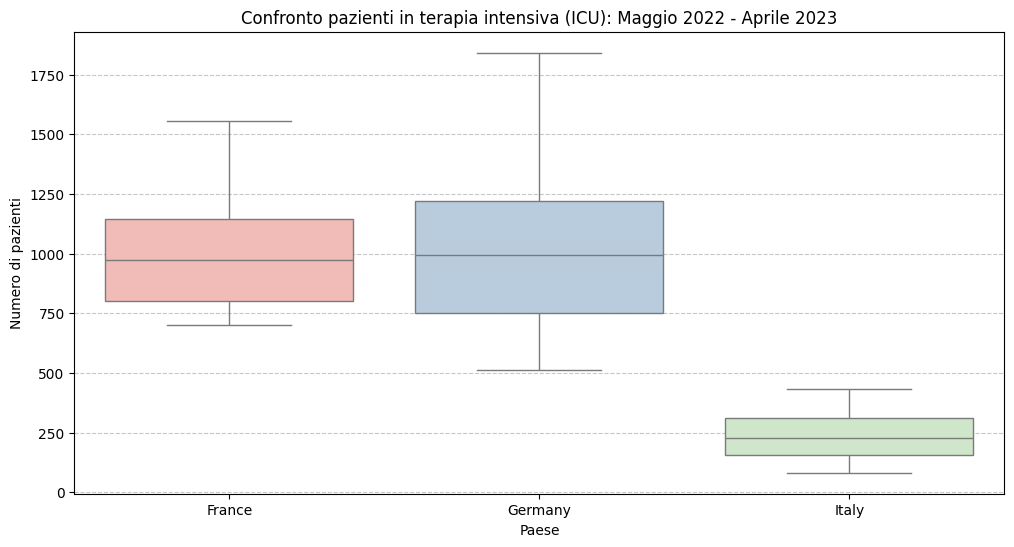

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definisco i paesi che voglio confrontare nel mio studio
paesi = ["Italy", "Germany", "France"]

# Filtro il dataset con le date esatte richieste dalla consegna
confronto_ue = df[(df["location"].isin(paesi)) &
                  (df["date"] >= "2022-05-01") &
                  (df["date"] <= "2023-04-30")].copy()

# Pulisco i dati: rimuovo le righe dove 'icu_patients' è vuoto
confronto_ue = confronto_ue.dropna(subset=["icu_patients"])

print("Statistiche descrittive (Maggio 2022 - Aprile 2023):")
print(confronto_ue.groupby("location")["icu_patients"].describe())

# Creo il Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x="location", y="icu_patients", data=confronto_ue, palette="Pastel1") #L'opzione palette="Pastel1" fa riferimento a una tavolozza di colori qualitativa.

plt.title("Confronto pazienti in terapia intensiva (ICU): Maggio 2022 - Aprile 2023")
plt.xlabel("Paese")
plt.ylabel("Numero di pazienti")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


B) **Commento:** Dall'analisi dei dati relativi al 2022, si osserva che la **Francia e la Germania** hanno mantenuto un numero di pazienti in terapia intensiva significativamente **più elevato rispetto all'Italia**. La **Francia presenta il valore medio più alto**; **l'Italia**, d'altra parte, **mostra una distribuzione più contenuta e stabile**, con un valore mediano di 327 pazienti, molto inferiore ai circa 1158 della Francia.

# **5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:**

**A) mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)**

**B) se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno**




['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe' 'European Union (27)' 'Faroe Islands' 'Falkland Islands' 'Fiji'
 'Finland' 'France' 'French Guiana' 'Fr

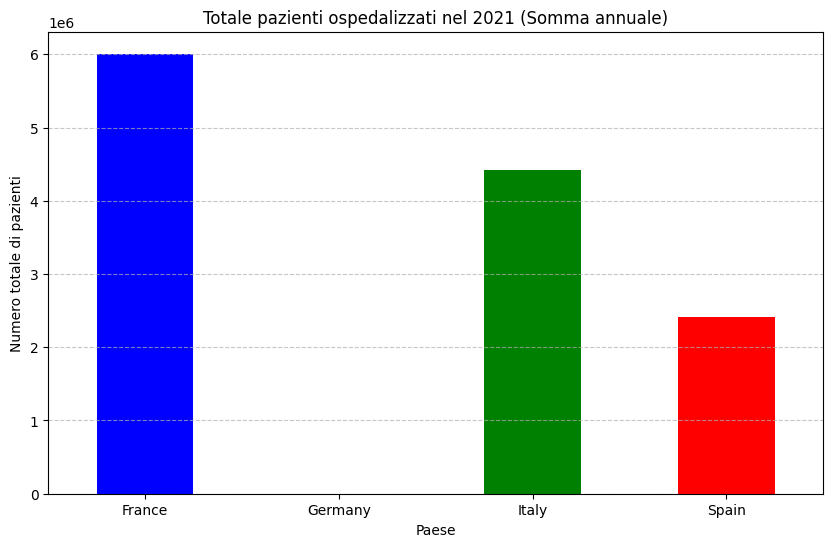

In [5]:
# Definisco i paesi richiesti
print(df["location"].unique())
paesi = ["Italy", "Germany", "France" , "Spain"]

# Filtro il dataset per l'intero anno 2021 e per i quattro paesi scelti
df['date'] = pd.to_datetime(df['date'])
confronto_2021 = df[(df["location"].isin(paesi)) & (df["date"].dt.year == 2021)].copy()

# Controllo quanti dati mancano
print("Conteggio dei dati validi per paese:")
print(confronto_2021.groupby("location")["hosp_patients"].count())

# Controllo germania
controllo_germania = df[(df["location"] == "Germany") & (df["date"].dt.year == 2021)]
print("Controllo dati ospedalizzati per la Germania (2021):")
print(controllo_germania[["date", "location", "hosp_patients"]].head(10))

# Calcolo la somma dei pazienti ospedalizzati
ospedalizzati_totali = confronto_2021.groupby("location")["hosp_patients"].sum()
print("\nSomma dei pazienti ospedalizzati nel 2021:")
print(ospedalizzati_totali)

# Visualizzazione grafica
plt.figure(figsize=(10, 6))
ospedalizzati_totali.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title("Totale pazienti ospedalizzati nel 2021 (Somma annuale)")
plt.xlabel("Paese")
plt.ylabel("Numero totale di pazienti")
plt.xticks(rotation=0) # Per tenere i nomi dei paesi dritti
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


B) **Analisi dei pazienti ospedalizzati (2021):**

Dall'analisi dei dati si osserva che per l'anno 2021 la colonna hosp_patients risulta completa per Italia, Francia e Spagna, mentre presenta zero record validi per la Germania.

**Gestione dei dati nulli:** Non è possibile, né consigliabile, gestire la mancanza di un intero anno di dati tramite tecniche di sostituzione (come l'imputazione della media o dello zero). Qualsiasi valore inserito sarebbe arbitrario e distorcerebbe il confronto statistico tra le nazioni. Pertanto, l'analisi si concentra esclusivamente sui dati reali disponibili, segnalando l'assenza di dati per il contesto tedesco nella variabile indicata.
